# News API Coverage Test
Compares article counts per test-set day across Alpha Vantage (cached), Finnhub, and Massive.

In [1]:
import os, json, time, requests, re
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path
import pytz
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")

FINNHUB_KEY = os.getenv("FINNHUB_API_KEY", "")
MASSIVE_KEY = os.getenv("MASSIVE_API_KEY", "")

print("Finnhub:", "OK" if FINNHUB_KEY else "MISSING")
print("Massive:", "OK" if MASSIVE_KEY else "MISSING")
print("Alpha Vantage cache:", "OK" if Path("../data/raw/av_news_raw.json").exists() else "MISSING")

Finnhub: OK
Massive: OK
Alpha Vantage cache: MISSING


In [2]:
# Load evaluation dates — walk-forward window, rows 250–437 (188 days)
prices = pd.read_csv("../data/processed/prices.csv", index_col="date", parse_dates=True)
prices = prices.dropna()
test_dates = prices.index[250:]
print(f"Eval set: {len(test_dates)} days ({test_dates[0].date()} \u2192 {test_dates[-1].date()})")

ET = pytz.timezone("America/New_York")

def leakage_safe_window(trading_day, prev_trading_day):
    start = ET.localize(datetime(prev_trading_day.year, prev_trading_day.month, prev_trading_day.day, 16))
    end   = ET.localize(datetime(trading_day.year, trading_day.month, trading_day.day, 16))
    return start, end

from_str = str((test_dates[0] - pd.Timedelta(days=1)).date())
to_str   = str(test_dates[-1].date())


Eval set: 188 days (2025-07-30 → 2026-04-28)


## Source 1: Alpha Vantage (cached)

In [3]:
raw_path = Path("../data/raw/av_news_raw.json")
av_articles = json.loads(raw_path.read_text()) if raw_path.exists() else []
print(f"Cached articles: {len(av_articles)}")

def av_count_for_day(trading_day, prev_day):
    start, end = leakage_safe_window(trading_day, prev_day)
    count = 0
    for art in av_articles:
        ts_str = art.get("time_published", "")
        if not ts_str:
            continue
        try:
            dt = datetime.strptime(ts_str, "%Y%m%dT%H%M%S")
            dt_et = pytz.utc.localize(dt).astimezone(ET)
            if start < dt_et <= end:
                count += 1
        except ValueError:
            continue
    return count

av_counts = {}
for i, day in enumerate(test_dates):
    prev = test_dates[i - 1] if i > 0 else day - timedelta(days=1)
    av_counts[str(day.date())] = av_count_for_day(day.to_pydatetime(), prev.to_pydatetime())

print(f"Days with articles: {sum(v > 0 for v in av_counts.values())}/{len(av_counts)}")

Cached articles: 0
Days with articles: 0/188


## Source 2: Finnhub

In [4]:
fh_resp = requests.get(
    f"https://finnhub.io/api/v1/company-news"
    f"?symbol=AAPL&from={from_str}&to={to_str}&token={FINNHUB_KEY}",
    timeout=15
)
fh_articles = fh_resp.json() if fh_resp.ok else []
print(f"Finnhub articles returned: {len(fh_articles)}")

def fh_count_for_day(trading_day, prev_day):
    start, end = leakage_safe_window(trading_day, prev_day)
    count = 0
    for art in fh_articles:
        try:
            dt_et = datetime.utcfromtimestamp(art["datetime"]).replace(tzinfo=pytz.utc).astimezone(ET)
            if start < dt_et <= end:
                count += 1
        except (KeyError, OSError):
            continue
    return count

fh_counts = {}
for i, day in enumerate(test_dates):
    prev = test_dates[i - 1] if i > 0 else day - timedelta(days=1)
    fh_counts[str(day.date())] = fh_count_for_day(day.to_pydatetime(), prev.to_pydatetime())

print(f"Days with articles: {sum(v > 0 for v in fh_counts.values())}/{len(fh_counts)}")

Finnhub articles returned: 246
Days with articles: 3/188


/var/folders/ms/_kbv0v1n1jg9qjkwwfszbd7h0000gn/T/ipykernel_12216/3726288255.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt_et = datetime.utcfromtimestamp(art["datetime"]).replace(tzinfo=pytz.utc).astimezone(ET)


## Source 3: Massive

In [5]:
def fetch_massive_all(ticker, from_date, to_date, api_key, limit=1000):
    articles = []
    url = (
        f"https://api.polygon.io/v2/reference/news"
        f"?ticker={ticker}&published_utc.gte={from_date}&published_utc.lte={to_date}"
        f"&limit={limit}&order=asc&apiKey={api_key}"
    )
    while url:
        resp = requests.get(url, timeout=15)
        if not resp.ok:
            print(f"  Massive error: {resp.status_code} {resp.text[:100]}")
            break
        data = resp.json()
        articles.extend(data.get("results", []))
        url = data.get("next_url", "")
        if url:
            url += f"&apiKey={api_key}"
            time.sleep(0.2)
    return articles

massive_articles = fetch_massive_all("AAPL", from_str, to_str, MASSIVE_KEY)
print(f"Massive articles returned: {len(massive_articles)}")

def massive_articles_for_day(trading_day, prev_day, articles):
    start, end = leakage_safe_window(trading_day, prev_day)
    result = []
    for art in articles:
        try:
            dt_et = datetime.fromisoformat(
                art["published_utc"].replace("Z", "+00:00")
            ).astimezone(ET)
            if start < dt_et <= end:
                result.append(art)
        except (KeyError, ValueError):
            continue
    return result

massive_counts = {}
for i, day in enumerate(test_dates):
    prev = test_dates[i - 1] if i > 0 else day - timedelta(days=1)
    massive_counts[str(day.date())] = len(massive_articles_for_day(
        day.to_pydatetime(), prev.to_pydatetime(), massive_articles
    ))

print(f"Days with articles: {sum(v > 0 for v in massive_counts.values())}/{len(massive_counts)}")

Massive articles returned: 1701


Days with articles: 188/188


## Source 4: GDELT — skipped (slow, ~40s)

In [6]:
# GDELT skipped — uncomment to run (~40 s, no API key needed)
# def fetch_gdelt_day(window_start, window_end):
#     fmt = "%Y%m%d%H%M%S"
#     s_utc = window_start.astimezone(pytz.utc).strftime(fmt)
#     e_utc = window_end.astimezone(pytz.utc).strftime(fmt)
#     url = (
#         "https://api.gdeltproject.org/api/v2/doc/doc"
#         f"?query=Apple+AAPL+stock&mode=artlist&maxrecords=250"
#         f"&startdatetime={s_utc}&enddatetime={e_utc}&format=json"
#     )
#     try:
#         resp = requests.get(url, timeout=20)
#         return len(resp.json().get("articles", [])) if resp.ok else 0
#     except Exception:
#         return 0
#
# gdelt_counts = {}
# for i, day in enumerate(test_dates):
#     prev = test_dates[i - 1] if i > 0 else day - timedelta(days=1)
#     start, end = leakage_safe_window(day.to_pydatetime(), prev.to_pydatetime())
#     gdelt_counts[str(day.date())] = fetch_gdelt_day(start, end)
#     time.sleep(0.5)
print("GDELT skipped.")

GDELT skipped.


## Comparison Table — All Articles

In [7]:
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Alpha Vantage": av_counts,
    "Finnhub":       fh_counts,
    "Massive":       massive_counts,
})
df.index.name = "date"

summary = pd.DataFrame({
    "Alpha Vantage": [f"{(df['Alpha Vantage']>0).sum()}/{len(df)} days"],
    "Finnhub":       [f"{(df['Finnhub']>0).sum()}/{len(df)} days"],
    "Massive":       [f"{(df['Massive']>0).sum()}/{len(df)} days"],
}, index=["coverage"])
print(summary.to_string())
print()

pd.set_option("display.max_rows", 50)
df.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=df.values.max())

         Alpha Vantage     Finnhub       Massive
coverage    0/188 days  3/188 days  188/188 days



,Alpha Vantage,Finnhub,Massive
date,,,
2025-07-30,0,0,5
2025-07-31,0,0,6
2025-08-01,0,0,11
2025-08-04,0,0,16
2025-08-05,0,0,11
2025-08-06,0,0,9
2025-08-07,0,0,6
2025-08-08,0,0,5
2025-08-11,0,0,20


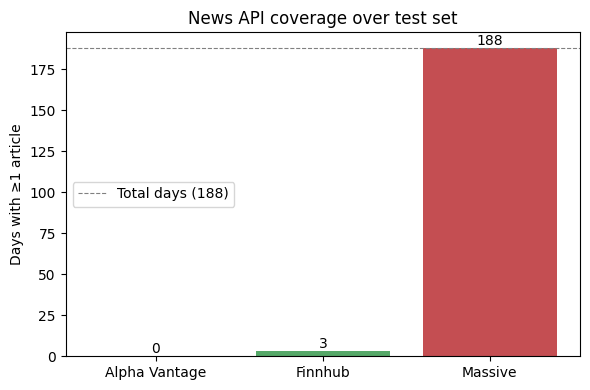

In [8]:
coverage = {src: (df[src] > 0).sum() for src in df.columns}
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(coverage.keys(), coverage.values(), color=["#4C72B0", "#55A868", "#C44E52"])
ax.axhline(len(df), color="gray", linestyle="--", linewidth=0.8, label=f"Total days ({len(df)})")
ax.bar_label(bars, fmt="%d")
ax.set_ylabel("Days with ≥1 article")
ax.set_title("News API coverage over test set")
ax.legend()
plt.tight_layout()
plt.show()

## Massive — Apple-Specific Filter
Keep only articles where the headline or description explicitly mentions **Apple** or **AAPL**.
This removes broad market articles that merely tag AAPL as a side mention.

In [9]:
APPLE_RE = re.compile(r"\bApple\b|\bAAPL\b", re.IGNORECASE)

def is_apple_specific(art):
    text = art.get("title", "") + " " + art.get("description", "")
    return bool(APPLE_RE.search(text))

massive_apple = [a for a in massive_articles if is_apple_specific(a)]
print(f"Total Massive articles:         {len(massive_articles)}")
print(f"Apple-specific (headline/desc): {len(massive_apple)}")
print(f"Filtered out:                   {len(massive_articles) - len(massive_apple)}")

Total Massive articles:         1701
Apple-specific (headline/desc): 623
Filtered out:                   1078


In [10]:
massive_apple_counts = {}
for i, day in enumerate(test_dates):
    prev = test_dates[i - 1] if i > 0 else day - timedelta(days=1)
    massive_apple_counts[str(day.date())] = len(massive_articles_for_day(
        day.to_pydatetime(), prev.to_pydatetime(), massive_apple
    ))

df_massive = pd.DataFrame({
    "Massive (all)": massive_counts,
    "Massive (Apple-specific)": massive_apple_counts,
})
df_massive.index.name = "date"

summary2 = pd.DataFrame({
    "Massive (all)":            [f"{(df_massive['Massive (all)']>0).sum()}/{len(df_massive)} days"],
    "Massive (Apple-specific)": [f"{(df_massive['Massive (Apple-specific)']>0).sum()}/{len(df_massive)} days"],
}, index=["coverage"])
print(summary2.to_string())
print()

df_massive.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=df_massive.values.max())

         Massive (all) Massive (Apple-specific)
coverage  188/188 days             169/188 days



,Massive (all),Massive (Apple-specific)
date,,
2025-07-30,5,1
2025-07-31,6,4
2025-08-01,11,4
2025-08-04,16,5
2025-08-05,11,4
2025-08-06,9,3
2025-08-07,6,4
2025-08-08,5,3
2025-08-11,20,6


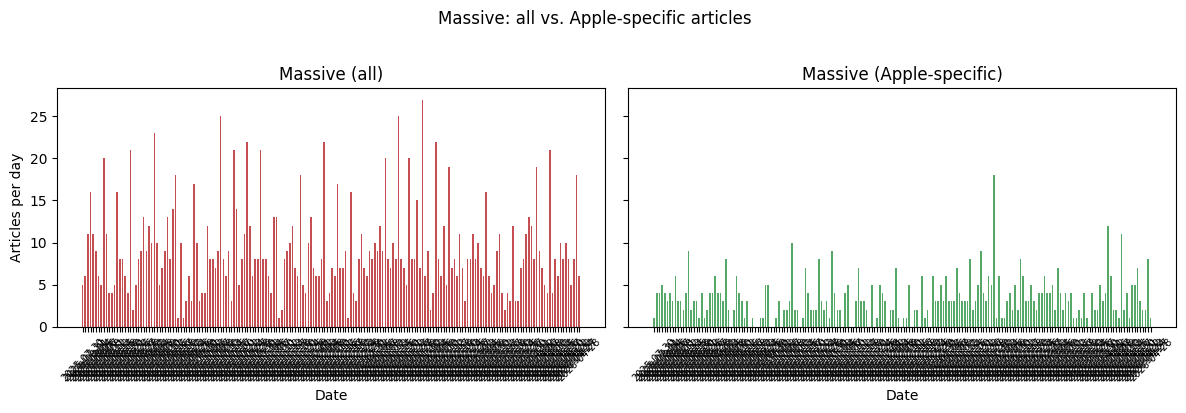

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col, color in zip(axes,
                          ["Massive (all)", "Massive (Apple-specific)"],
                          ["#C44E52", "#55A868"]):
    ax.bar(df_massive.index, df_massive[col], color=color, width=0.6)
    ax.set_title(col)
    ax.set_xlabel("Date")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
axes[0].set_ylabel("Articles per day")
plt.suptitle("Massive: all vs. Apple-specific articles", y=1.02)
plt.tight_layout()
plt.show()

## Massive — Example Headlines per Day

In [12]:
rows = []
for i, day in enumerate(test_dates):
    prev = test_dates[i - 1] if i > 0 else day - timedelta(days=1)
    day_arts = massive_articles_for_day(day.to_pydatetime(), prev.to_pydatetime(), massive_apple)
    headlines = " | ".join(a["title"] for a in day_arts[:3])
    rows.append({
        "date":       str(day.date()),
        "n_articles": len(day_arts),
        "headlines":  headlines if headlines else "—",
    })

df_examples = pd.DataFrame(rows).set_index("date")
pd.set_option("display.max_colwidth", 120)
df_examples.style.background_gradient(subset=["n_articles"], cmap="RdYlGn")

,n_articles,headlines
date,,
2025-07-30,1,"AAPL INVESTOR ALERT: Bronstein, Gewirtz & Grossman LLC Announces that Apple Inc. Investors with Substantial Losses Have Opportunity to Lead Class Action Lawsuit"
2025-07-31,4,"Meet the Unstoppable Stock That Could Join Nvidia, Microsoft, and Apple in the $3 Trillion Club | S&P 500: Will Strong Earnings From Big Tech Keep Outweighing Trade Risks? | Alphabet's Recent Numbers Were Strong, but This Metric Could be a Red Flag"
2025-08-01,4,"These 3 Funds Squeeze Apple and Microsoft for Dividends up to 11% | Apple Stock: Big Earnings, Small Move—Time to Buy? | Apple: AI-Focused Growth Strategy Positions Stock for Long-Term Outperformance"
2025-08-04,5,Apple’s AI Gamble: Is It Smart Patience or Just Falling Behind? | Here's How Alphabet Can Become the World's Second $4 Trillion Company | AAPL LEGAL ALERT: Lose Money on Your Apple Inc. Investment? Contact BFA Law by August 19 Class Action Deadline (NASDAQ:AAPL)
2025-08-05,4,"1 Unstoppable Stock That Could Join Nvidia, Microsoft, and Apple in the $3 Trillion Club | Apple Stock Analysis: Buy or Sell? | Apple's App Store Booms, But The Stock Lags: Is It Time To Buy?"
2025-08-06,3,"In-Vehicle Apps Market Growth Trends and Competitive Strategies Report 2025-2033 | Apple, Google, Microsoft, Toyota, and Others Prioritize Innovation and Interoperability in Auto Tech Advancements | With Apple Starting to See iPhone Sales Momentum, Is Now the Time to Buy the Stock? | Why MP Materials Stock Surged an Incredible 85% in July"
2025-08-07,4,S&P 500: Quiet Rage-Bound Price Action Masks Critical Yield Curve Developments | Apple Isn't Losing the AI Race. It's Playing a Different Game. | Apple: Why the Stock Is Protected From Trump Admin’s Semiconductor Tariff Plans
2025-08-08,3,Stock Market Today: Apple Gains 3% as Investors React to AI Momentum and $600 Billion U.S. Investment Commitment | Here's Why MP Materials Stock Surged Again This Week | Nasdaq 100 Poised for New ATHs?
2025-08-11,6,"Apple's New Artificial Intelligence (AI) Strategy Could Be a Genius Move | AAPL NEWS: Did Apple Inc. Mislead Investors? Contact BFA Law by August 19 Class Action Deadline (NASDAQ:AAPL) | Microsoft, Apple, Amazon, and Meta Just Gave Nvidia Investors Great News"


## Massive — Full Article Detail (Title · Description · AAPL Insight)

In [13]:
TWO_YEAR_FROM = "2024-04-29"
TWO_YEAR_TO   = "2026-04-29"

print(f"Fetching Massive articles from {TWO_YEAR_FROM} to {TWO_YEAR_TO} …")
massive_2y = fetch_massive_all("AAPL", TWO_YEAR_FROM, TWO_YEAR_TO, MASSIVE_KEY)
massive_2y_apple = [a for a in massive_2y if is_apple_specific(a)]
print(f"Total articles: {len(massive_2y)}  |  Apple-specific: {len(massive_2y_apple)}")

detail_rows = []
for art in massive_2y_apple:
    aapl_insight = next(
        (ins for ins in art.get("insights", []) if ins.get("ticker") == "AAPL"), {}
    )
    published_et = datetime.fromisoformat(
        art["published_utc"].replace("Z", "+00:00")
    ).astimezone(ET)
    detail_rows.append({
        "date":           str(published_et.date()),
        "time":           published_et.strftime("%H:%M ET"),
        "source":         art.get("publisher", {}).get("name", ""),
        "title":          art.get("title", ""),
        "description":    art.get("description", ""),
        "aapl_sentiment": aapl_insight.get("sentiment", ""),
        "aapl_insight":   aapl_insight.get("sentiment_reasoning", ""),
    })

df_detail_2y = pd.DataFrame(detail_rows)
print(f"Rows in dataframe: {len(df_detail_2y)}")

SENTIMENT_COLORS = {"positive": "#c6efce", "negative": "#ffc7ce", "neutral": "#ffeb9c", "": "white"}

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 2000)
df_detail_2y.style \
    .map(lambda v: f"background-color: {SENTIMENT_COLORS.get(v, 'white')}",
         subset=["aapl_sentiment"]) \
    .set_properties(**{"text-align": "left", "vertical-align": "top", "white-space": "pre-wrap"}) \
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])

Total AAPL articles (2y):          3000
With description available:         3000


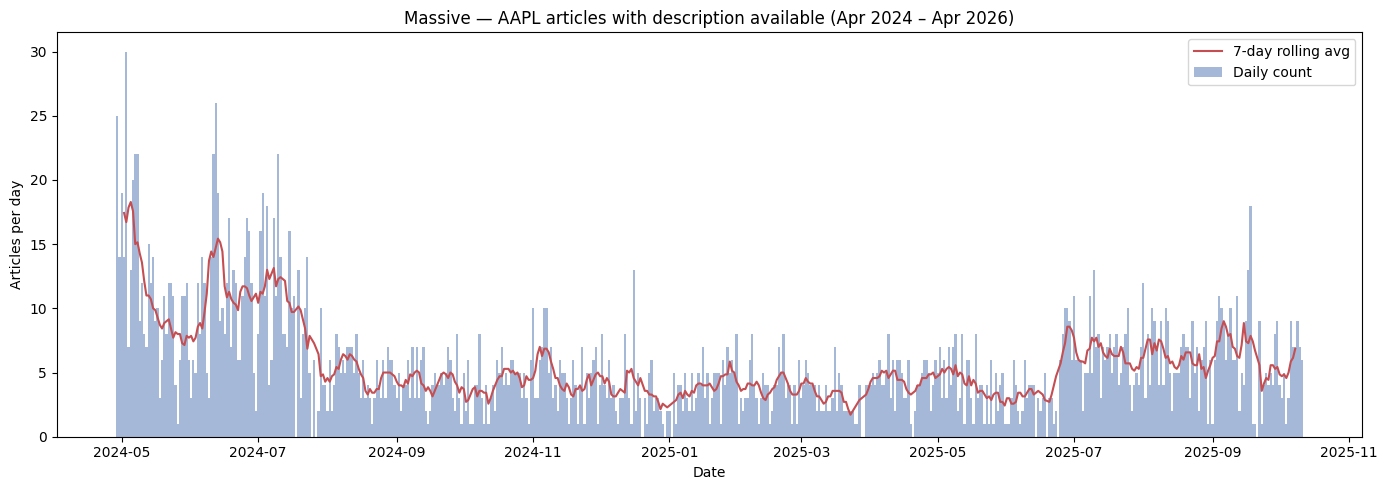


Monthly totals:
2024-04     39
2024-05    357
2024-06    326
2024-07    285
2024-08    152
2024-09    126
2024-10    125
2024-11    143
2024-12    109
2025-01    123
2025-02    104
2025-03     93
2025-04    130
2025-05    129
2025-06    112
2025-07    196
2025-08    195
2025-09    195
2025-10     61


In [14]:
# All AAPL-tagged articles with a description available, grouped by day
massive_2y_with_desc = [a for a in massive_2y if a.get("description", "").strip()]
print(f"Total AAPL articles (2y):          {len(massive_2y)}")
print(f"With description available:         {len(massive_2y_with_desc)}")

dates_series = pd.to_datetime([
    a["published_utc"][:10] for a in massive_2y_with_desc
])
daily_counts = dates_series.value_counts().sort_index()
daily_counts.index = pd.to_datetime(daily_counts.index)
rolling_7 = daily_counts.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(daily_counts.index, daily_counts.values, color="#4C72B0", alpha=0.5, width=1, label="Daily count")
ax.plot(rolling_7.index, rolling_7.values, color="#C44E52", linewidth=1.5, label="7-day rolling avg")
ax.set_xlabel("Date")
ax.set_ylabel("Articles per day")
ax.set_title("Massive — AAPL articles with description available (Apr 2024 – Apr 2026)")
ax.legend()
plt.tight_layout()
plt.show()

# Monthly summary table
monthly = daily_counts.resample("ME").sum().rename("articles")
monthly.index = monthly.index.strftime("%Y-%m")
print("\nMonthly totals:")
print(monthly.to_string())